In [1]:
import os
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical

In [2]:
BASE_PATH = Path(r"E:\Thesis")

HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

OUT_DIR = BASE_PATH / "outputs" / "densenet201_pad_to_ham_baseline"
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (250, 250)   # আগের মতোই resize
BATCH_SIZE = 4          # GTX 1650 safe start
EPOCHS = 20
CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

print("Output folder:", OUT_DIR)

Output folder: E:\Thesis\outputs\densenet201_pad_to_ham_baseline


In [3]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.10.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
!nvidia-smi

Sat Aug 22 11:44:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.88                 KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   69C    P8              2W /   50W |    1323MiB /   4096MiB |     13%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
ham = pd.read_csv(HAM_PATH / "HAM10000_metadata.csv")
pad = pd.read_csv(PAD_PATH / "metadata.csv")

print("HAM shape:", ham.shape)
print("PAD shape:", pad.shape)

HAM shape: (10015, 8)
PAD shape: (2298, 26)


In [6]:
HAM_CLASSES = ["akiec", "bcc", "mel", "nv"]
PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

ham_4 = ham[ham["dx"].isin(HAM_CLASSES)].copy()
ham_4["label"] = ham_4["dx"].map({
    "akiec": "ACK",
    "bcc": "BCC",
    "mel": "MEL",
    "nv": "NEV"
})

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]

print("HAM class counts:")
print(ham_4["label"].value_counts())

print("\nPAD class counts:")
print(pad_4["label"].value_counts())

HAM class counts:
label
NEV    6705
MEL    1113
BCC     514
ACK     327
Name: count, dtype: int64

PAD class counts:
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [7]:
ham_4["image_path"] = ham_4["image_id"].apply(lambda x: str(HAM_IMAGE_DIR / f"{x}.jpg"))
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))

ham_4["exists"] = ham_4["image_path"].apply(os.path.exists)
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print("HAM exists:")
print(ham_4["exists"].value_counts())

print("\nPAD exists:")
print(pad_4["exists"].value_counts())

HAM exists:
exists
True    8659
Name: count, dtype: int64

PAD exists:
exists
True    1871
Name: count, dtype: int64


In [8]:
print("HAM labels:", sorted(ham_4["label"].unique()))
print("PAD labels:", sorted(pad_4["label"].unique()))
print("Same classes:", set(ham_4["label"].unique()) == set(pad_4["label"].unique()))

HAM labels: ['ACK', 'BCC', 'MEL', 'NEV']
PAD labels: ['ACK', 'BCC', 'MEL', 'NEV']
Same classes: True


In [9]:
possible_group_cols = ["lesion_id", "patient_id"]
group_col = next((c for c in possible_group_cols if c in pad_4.columns), None)

if group_col is not None:
    print("Using group column:", group_col)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    train_idx, val_idx = next(gss.split(pad_4, groups=pad_4[group_col]))
    train_df = pad_4.iloc[train_idx].copy()
    val_df = pad_4.iloc[val_idx].copy()
else:
    print("No group column found. Using stratified split.")
    train_df, val_df = train_test_split(
        pad_4,
        test_size=0.20,
        random_state=42,
        stratify=pad_4["label"]
    )

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("HAM test samples:", len(ham_4))

Using group column: lesion_id
Training samples: 1492
Validation samples: 379
HAM test samples: 8659


In [10]:
train_df.to_csv(OUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUT_DIR / "val_split.csv", index=False)
ham_4.to_csv(OUT_DIR / "ham_test_split.csv", index=False)

In [11]:
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
ham_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

ham_generator = ham_datagen.flow_from_dataframe(
    dataframe=ham_4,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Train samples:", train_generator.samples)
print("Val samples:", val_generator.samples)
print("HAM test samples:", ham_generator.samples)

Found 1492 validated image filenames belonging to 4 classes.
Found 379 validated image filenames belonging to 4 classes.
Found 8659 validated image filenames belonging to 4 classes.
Train samples: 1492
Val samples: 379
HAM test samples: 8659


In [12]:
base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(4, activation="softmax", dtype="float32")(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 250, 250, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 256, 256, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 125, 125, 64  9408        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                              

In [13]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
csv_logger = CSVLogger(str(OUT_DIR / "history.csv"), append=False)

checkpoint = ModelCheckpoint(
    filepath=str(OUT_DIR / "best_model.keras"),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [17]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[csv_logger, checkpoint, reduce_lr]
)

Epoch 1/20
373/373 [==============================] - ETA: 0s - loss: 0.4878 - accuracy: 0.7956
Epoch 1: val_accuracy improved from -inf to 0.73087, saving model to E:\Thesis\outputs\densenet201_pad_to_ham_baseline\best_model.keras
373/373 [==============================] - 117s 315ms/step - loss: 0.4878 - accuracy: 0.7956 - val_loss: 0.6739 - val_accuracy: 0.7309 - lr: 5.0000e-04
Epoch 2/20
373/373 [==============================] - ETA: 0s - loss: 0.4490 - accuracy: 0.8170
Epoch 2: val_accuracy did not improve from 0.73087
373/373 [==============================] - 122s 327ms/step - loss: 0.4490 - accuracy: 0.8170 - val_loss: 0.7229 - val_accuracy: 0.7230 - lr: 5.0000e-04
Epoch 3/20
373/373 [==============================] - ETA: 0s - loss: 0.4736 - accuracy: 0.8063
Epoch 3: val_accuracy improved from 0.73087 to 0.75726, saving model to E:\Thesis\outputs\densenet201_pad_to_ham_baseline\best_model.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
373/3

In [18]:
history_clean = {}
for k, v in history.history.items():
    history_clean[k] = [float(x) for x in v]

with open(OUT_DIR / "history.json", "w") as f:
    json.dump(history_clean, f, indent=2)

pd.DataFrame(history.history).to_csv(OUT_DIR / "history_full.csv", index=False)

with open(OUT_DIR / "history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved.")

Training history saved.


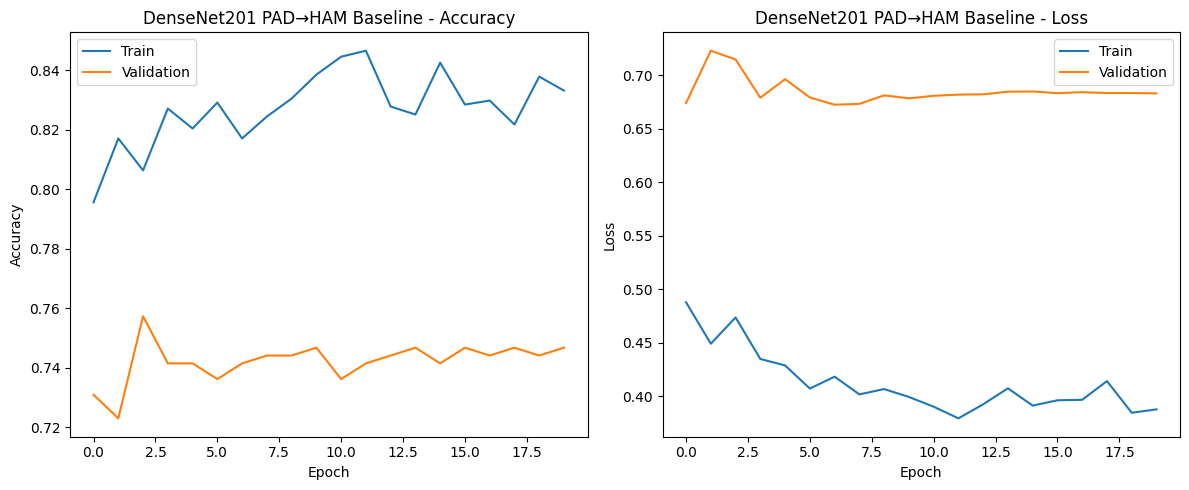

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("DenseNet201 PAD→HAM Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("DenseNet201 PAD→HAM Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
best_model = tf.keras.models.load_model(OUT_DIR / "best_model.keras")
print("Best model loaded.")

Best model loaded.


In [21]:
ham_loss, ham_accuracy = best_model.evaluate(ham_generator, verbose=1)
print("HAM Accuracy:", ham_accuracy)
print("HAM Loss:", ham_loss)

2165/2165 [==============================] - 323s 145ms/step - loss: 2.4604 - accuracy: 0.3208
HAM Accuracy: 0.32082226872444153
HAM Loss: 2.460374355316162


In [22]:
pred_probs = best_model.predict(ham_generator, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = ham_generator.classes

2165/2165 [==============================] - 186s 82ms/step


In [23]:
acc = accuracy_score(true_classes, pred_classes)
prec = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
rec = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Accuracy : 0.3208222658505601
Precision: 0.3201869838333703
Recall   : 0.370725936522131
F1 Score : 0.22534854271686444
              precision    recall  f1-score   support

         ACK       0.06      0.51      0.10       327
         BCC       0.10      0.53      0.17       514
         MEL       0.23      0.11      0.14      1113
         NEV       0.89      0.33      0.48      6705

    accuracy                           0.32      8659
   macro avg       0.32      0.37      0.23      8659
weighted avg       0.73      0.32      0.41      8659



In [24]:
true_onehot = to_categorical(true_classes, num_classes=4)

auc = roc_auc_score(
    true_onehot,
    pred_probs,
    multi_class="ovr",
    average="macro"
)

print("Macro AUC:", auc)

Macro AUC: 0.6611994197445705


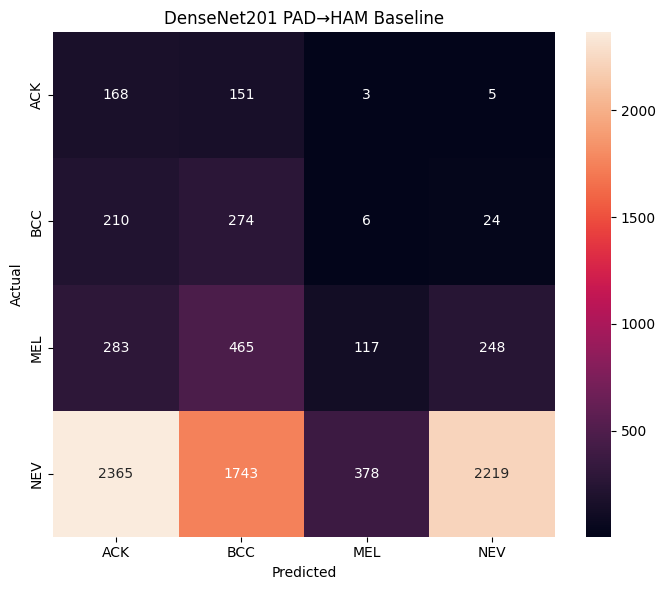

In [25]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet201 PAD→HAM Baseline")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
results = pd.DataFrame({
    "Experiment": ["DenseNet201 PAD→HAM Baseline"],
    "HAM Accuracy": [acc],
    "Macro Precision": [prec],
    "Macro Recall": [rec],
    "Macro F1": [f1],
    "Macro AUC": [auc]
})

print(results)
results.to_csv(OUT_DIR / "final_results.csv", index=False)

                     Experiment  HAM Accuracy  Macro Precision  Macro Recall  \
0  DenseNet201 PAD→HAM Baseline      0.320822         0.320187      0.370726   

   Macro F1  Macro AUC  
0  0.225349   0.661199  


In [ ]:
with open(OUT_DIR / "run_info.txt", "w") as f:
    f.write("Experiment: DenseNet201 PAD→HAM Baseline\n")
    f.write(f"HAM accuracy: {acc}\n")
    f.write(f"HAM precision: {prec}\n")
    f.write(f"HAM recall: {rec}\n")
    f.write(f"HAM f1: {f1}\n")
    f.write(f"HAM auc: {auc}\n")
print("All outputs saved in:", OUT_DIR)

All outputs saved in: E:\Thesis\outputs\densenet201_pad_to_ham_baseline
